# lineitem - Experiment 3: OVC Comparison Analysis


In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp3_output'


# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [2]:
def parse_log_file(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 51 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [3]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

In [4]:
# Load Exp1 data for comparison with Exp3.1
print("="*100)
print("EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - WITH OVC")
print("="*100)
df_exp1 = df_all[df_all['experiment'] == 'Exp1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp1[display_cols].to_string(index=False))
if not df_exp1.empty:
    print(f"\nOptimal: {df_exp1.loc[df_exp1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp1['total_time'].min():.1f}s")
    print(f"Worst: {df_exp1.loc[df_exp1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp1['total_time'].max():.1f}s")

EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - WITH OVC
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       176     2692.66      2107.48      585.18        1.11             1                1.00
       8       352     1557.55      1135.38      422.17        1.93             1                1.00
      16       704      928.90       618.52      310.38        3.23             1                1.01
      24      1056      757.50       490.92      266.58        3.96             1                1.02
      32      1408      739.07       432.11      306.96        4.06             2                1.22
      40      1760      719.29       372.39      346.90        4.17             3                1.43
      44      1935      737.70       374.15      363.55        4.07             3                1.50

Optimal: 40 threads @ 719.3s
Worst: 4 threads @ 2692.7s


In [5]:
# Load Exp2 data (OVC enabled)
print("\n" + "="*100)
print("EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITH OVC")
print("="*100)
df_exp2 = df_all[df_all['experiment'] == 'Exp2'].sort_values('memory_gb')
display_cols = ['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp2[display_cols].to_string(index=False))
if not df_exp2.empty:
    print(f"\nOptimal: {df_exp2.loc[df_exp2['total_time'].idxmin(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].min():.1f}s")
    print(f"Worst: {df_exp2.loc[df_exp2['total_time'].idxmax(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].max():.1f}s")


EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITH OVC
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      3500      797.29       368.47      428.81        3.76             9                1.76
         4       919      619.49       388.85      230.64        4.84             1                1.02
         6       639      630.96       398.34      232.61        4.75             1                1.02
         8       480      636.89       413.83      223.06        4.71             1                1.01
        16       279      665.78       450.49      215.29        4.51             1                1.01
        24       200      749.92       536.12      213.80        4.00             1                1.01
        32       160      756.77       549.36      207.41        3.96             1                1.00

Optimal: 4GB @ 619.5s
Worst: 1GB @ 797.3s


In [6]:
# Load Exp3 data (OVC disabled)
print("\n" + "="*100)
print("EXP3: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITHOUT OVC")
print("="*100)
df_exp3 = df_all[df_all['experiment'] == 'Exp3'].sort_values('memory_gb')
display_cols = ['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp3[display_cols].to_string(index=False))
if not df_exp3.empty:
    print(f"\nOptimal: {df_exp3.loc[df_exp3['total_time'].idxmin(), 'memory_gb']:.0f}GB @ {df_exp3['total_time'].min():.1f}s")
    print(f"Worst: {df_exp3.loc[df_exp3['total_time'].idxmax(), 'memory_gb']:.0f}GB @ {df_exp3['total_time'].max():.1f}s")


EXP3: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITHOUT OVC
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      3500     1230.80       459.86      770.94        2.44             9                1.95
         2      1760     1074.80       466.16      608.64        2.79             3                1.56
         4       919      879.99       486.80      393.19        3.41             1                1.02
         6       639      925.04       507.14      417.90        3.24             1                1.01
         8       480      922.23       525.28      396.95        3.25             1                1.01
        16       279      980.30       568.60      411.70        3.06             1                1.01
        24       200     1031.58       635.17      396.41        2.91             1                1.00
        32       160     1026.06       623.06      403.00        2.92             1                

In [7]:
colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

### Exp3.1: OVC Scalability Comparison (Exp1 vs Exp3.1)

In [8]:
# Exp3.1: OVC Scalability Comparison - Load and display data
print("="*100)
print("EXP3.1: NON-OVC SCALABILITY TEST (2GB RAM, Varying Threads)")
print("="*100)
df_exp3_1 = df_all[df_all['experiment'] == 'Exp3.1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp3_1[display_cols].to_string(index=False))

if len(df_exp3_1) > 0:
    print(f"\nOptimal: {df_exp3_1.loc[df_exp3_1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp3_1['total_time'].min():.1f}s")
    print(f"Worst: {df_exp3_1.loc[df_exp3_1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp3_1['total_time'].max():.1f}s")
    
    # Compare with Exp1 (OVC enabled)
    print("\n" + "="*100)
    print("COMPARISON: OVC vs NON-OVC SCALABILITY")
    print("="*100)
    
    # Merge Exp1 and Exp3.1 data
    comparison = pd.merge(
        df_exp1[['threads', 'total_time', 'rungen_time', 'merge_time', 'throughput']],
        df_exp3_1[['threads', 'total_time', 'rungen_time', 'merge_time', 'throughput']],
        on='threads', suffixes=('_ovc', '_no_ovc')
    )
    comparison['speedup_pct'] = ((comparison['total_time_no_ovc'] / comparison['total_time_ovc']) - 1) * 100
    
    print(comparison[['threads', 'total_time_ovc', 'total_time_no_ovc', 'speedup_pct']].to_string(index=False))
    print(f"\nAverage OVC speedup: {comparison['speedup_pct'].mean():.1f}%")
    print(f"Best OVC speedup: {comparison['speedup_pct'].max():.1f}% at {comparison.loc[comparison['speedup_pct'].idxmax(), 'threads']:.0f} threads")
    print(f"Worst OVC speedup: {comparison['speedup_pct'].min():.1f}% at {comparison.loc[comparison['speedup_pct'].idxmin(), 'threads']:.0f} threads")
else:
    print("\n⚠️  No Exp3.1 data found. Make sure Exp3.1 log files are in the result directory.")

EXP3.1: NON-OVC SCALABILITY TEST (2GB RAM, Varying Threads)
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       176     3046.99      2247.65      799.34        0.98             1                1.00
       8       352     1799.21      1209.43      589.78        1.67             1                1.00
      16       704     1182.35       701.56      480.80        2.54             1                1.01
      24      1056      972.58       536.31      436.27        3.08             1                1.01
      32      1408     1117.52       512.17      605.35        2.68             2                1.28
      40      1760     1098.16       472.16      626.00        2.73             3                1.56
      44      1935     1188.25       474.86      713.39        2.52             3                1.65

Optimal: 24 threads @ 972.6s
Worst: 4 threads @ 3047.0s

COMPARISON: OVC vs NON-OVC SCALABILITY
 threads  total_time_ovc  t

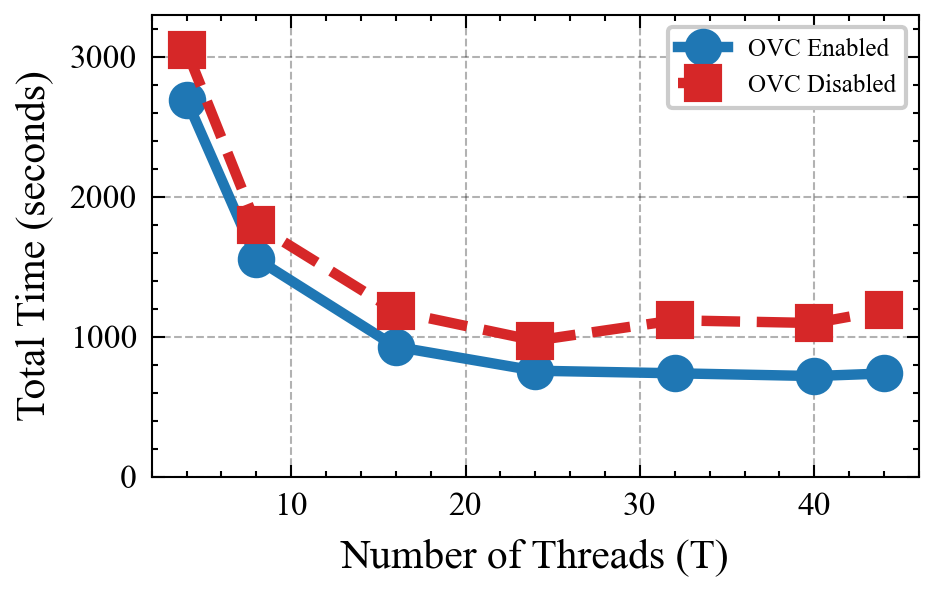

In [9]:
# Exp3.1 Plot 1: Total Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['total_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled')
    ax.plot(threads, df_exp3_1_sorted['total_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled')
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Total Time (seconds)')
    # ax.set_title('Scalability: OVC vs Non-OVC (2GB RAM)', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0, top=3300)
    
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_total_time.png'), dpi=300)
    plt.show()


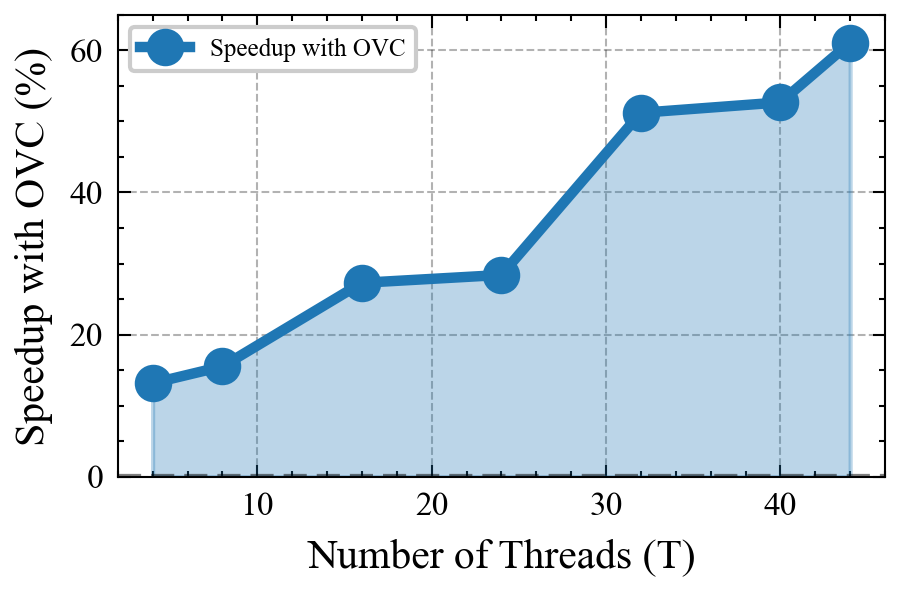

In [10]:
# Exp3.1 Plot 2: Speedup Percentage
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    # Calculate speedup with OVC (positive = OVC is faster)
    speedup_pct = ((df_exp3_1_sorted['total_time'].values / df_exp1_sorted['total_time'].values) - 1) * 100
    
    ax.plot(threads, speedup_pct, 'o-', lw=2.5, markersize=8, color='#1f77b4', label='Speedup with OVC')
    ax.axhline(y=0, color='black', linestyle='--', lw=1.5, alpha=0.5)
    ax.fill_between(threads, 0, speedup_pct, alpha=0.3, color='#1f77b4')
    
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Speedup with OVC (%)')
    # ax.set_title('OVC Performance Benefit by Thread Count', fontweight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='upper left')
    ax.set_ylim(bottom=0, top=65)
    
    # plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_speedup.png'), dpi=300)
    plt.show()


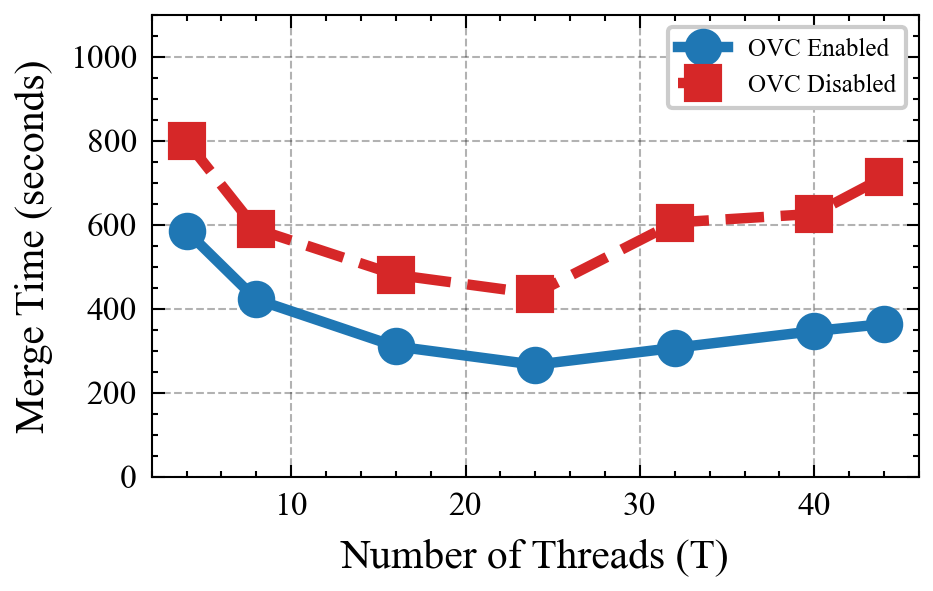

In [11]:
# Exp3.1 Plot 3: Merge Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['merge_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled')
    ax.plot(threads, df_exp3_1_sorted['merge_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled')
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Merge Time (seconds)')
    # ax.set_title('Merge Phase: OVC Impact', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0, top=1100)
    
    # plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_merge_time.png'), dpi=300)
    plt.show()


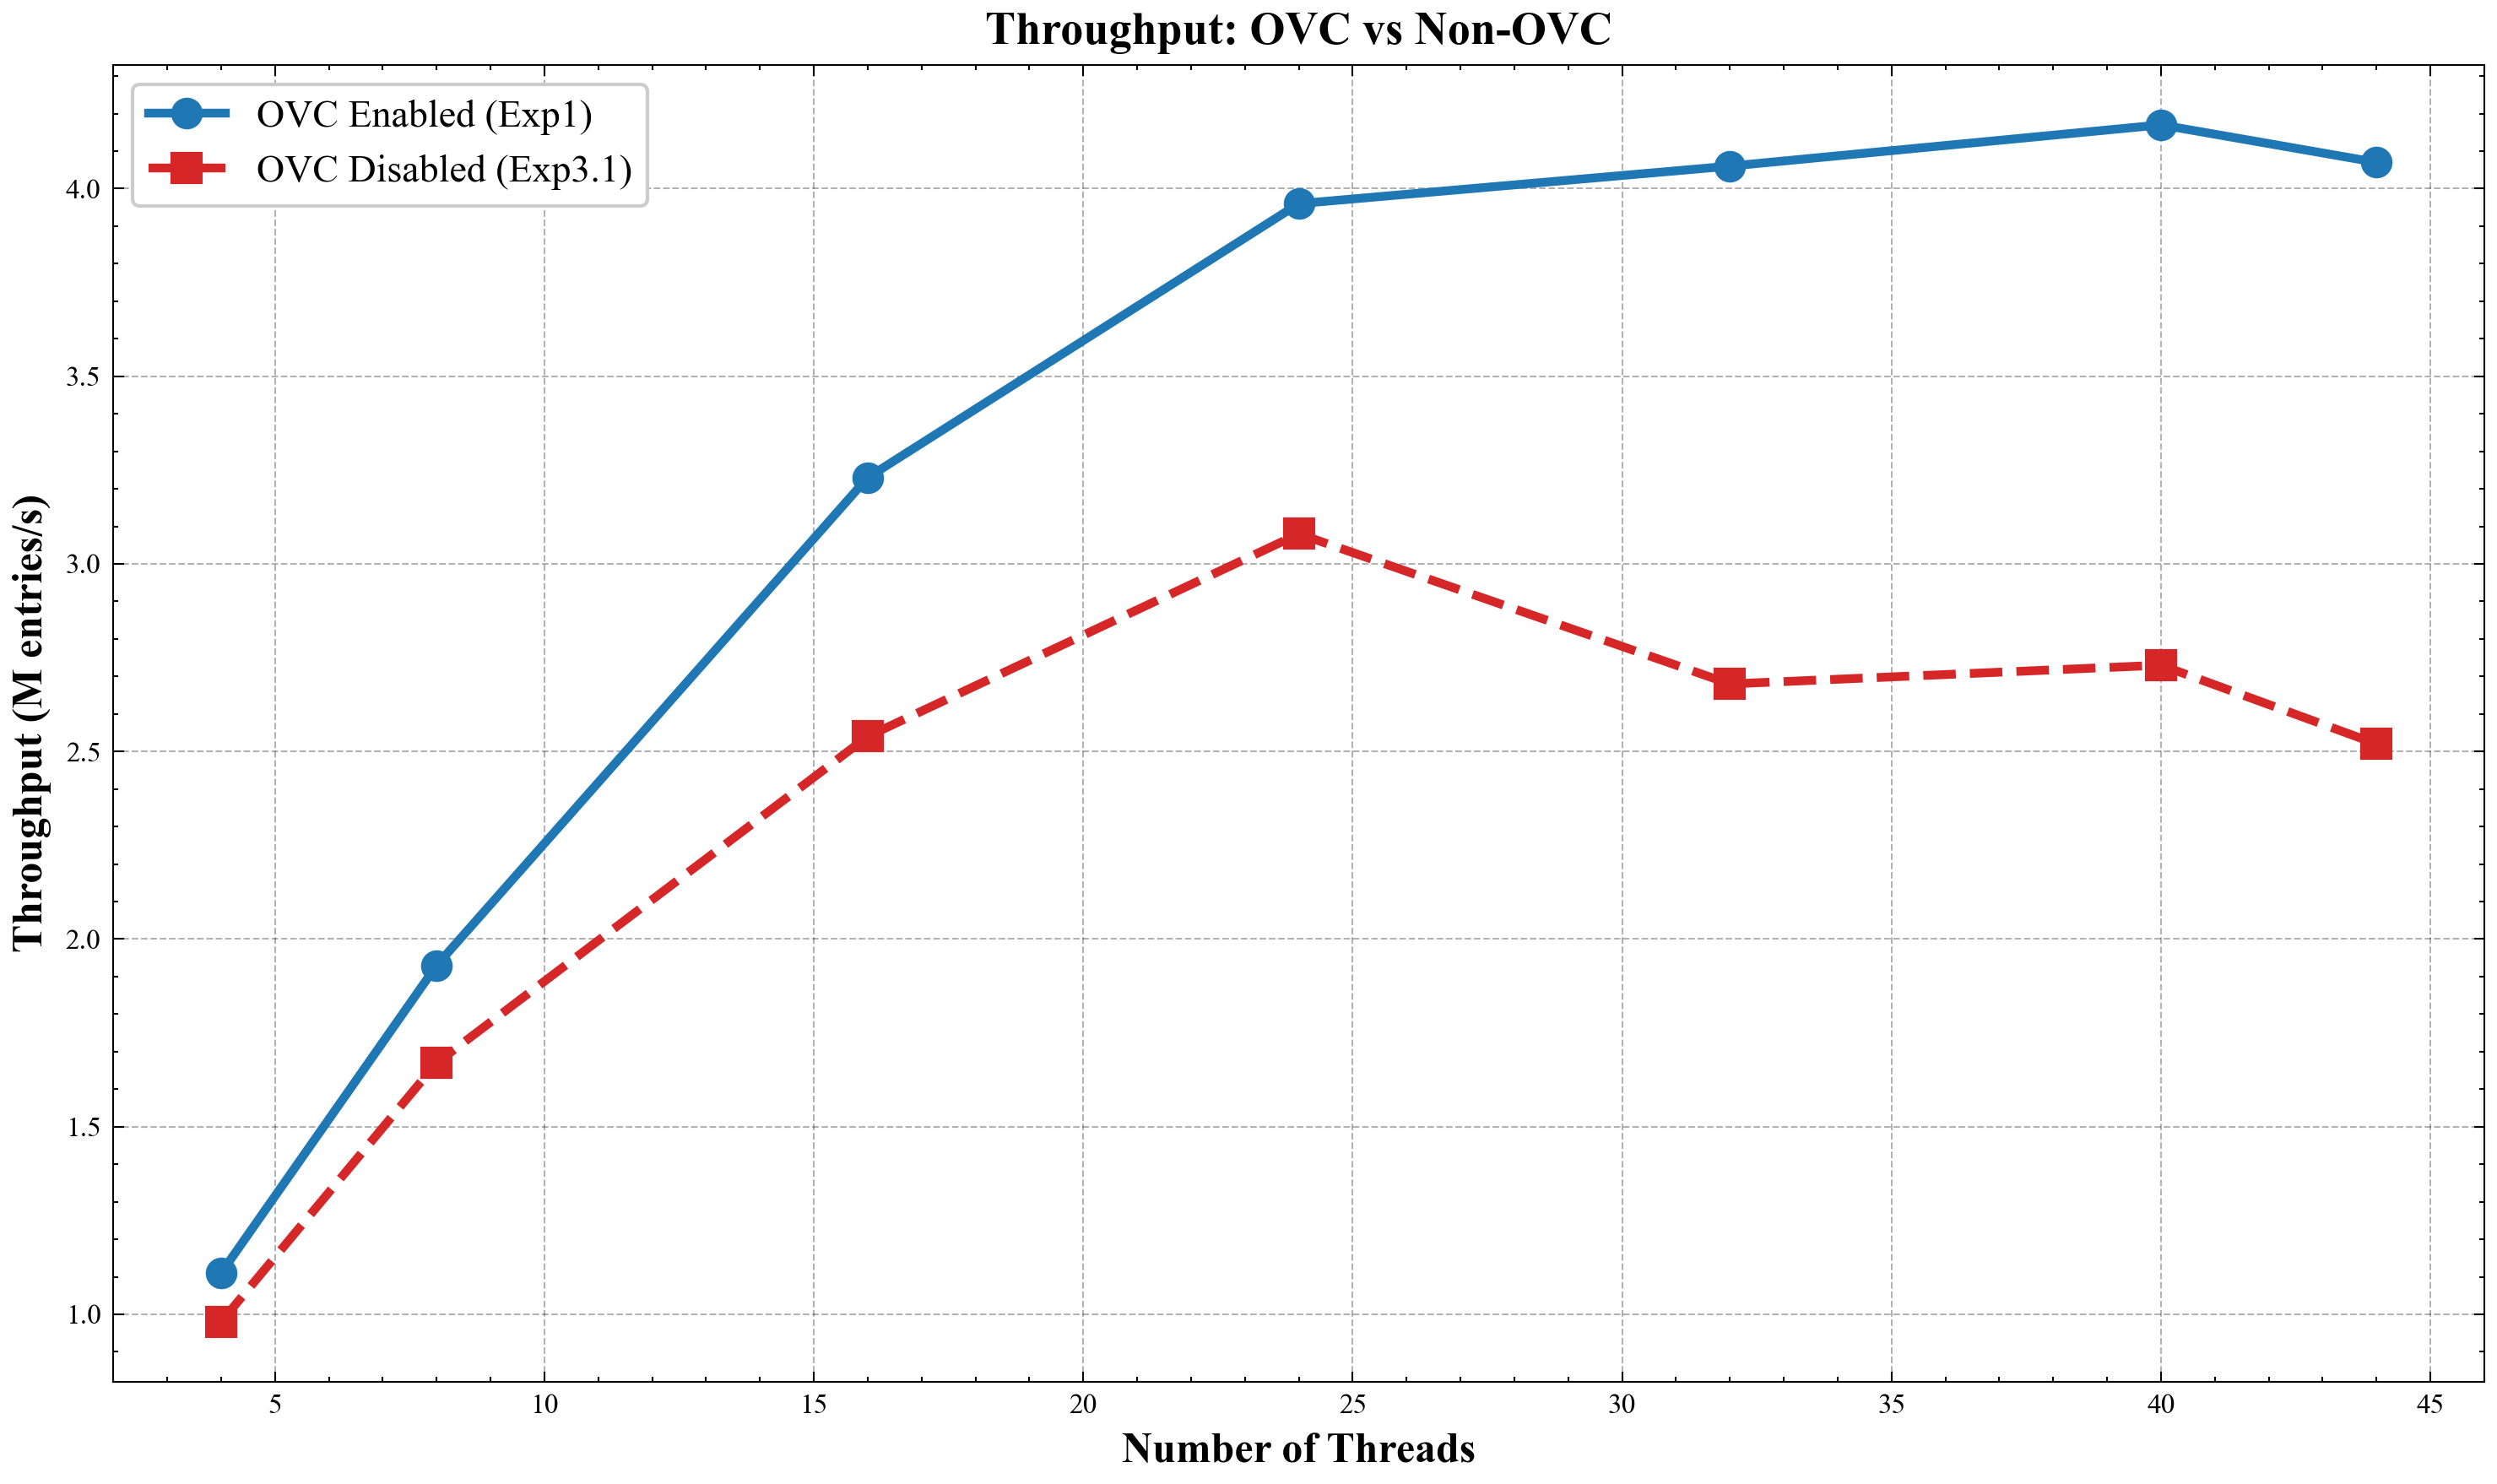


📊 Exp3.1 Insight: OVC provides 35.6% average speedup across thread counts in scalability tests.


In [12]:
# Exp3.1 Plot 4: Throughput Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['throughput'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled (Exp1)')
    ax.plot(threads, df_exp3_1_sorted['throughput'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled (Exp3.1)')
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('Throughput (M entries/s)', fontweight='bold', fontsize=12)
    ax.set_title('Throughput: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_throughput.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    speedup_pct = ((df_exp3_1_sorted['total_time'].values / df_exp1_sorted['total_time'].values) - 1) * 100
    print(f"\n📊 Exp3.1 Insight: OVC provides {speedup_pct.mean():.1f}% average speedup across thread counts in scalability tests.")


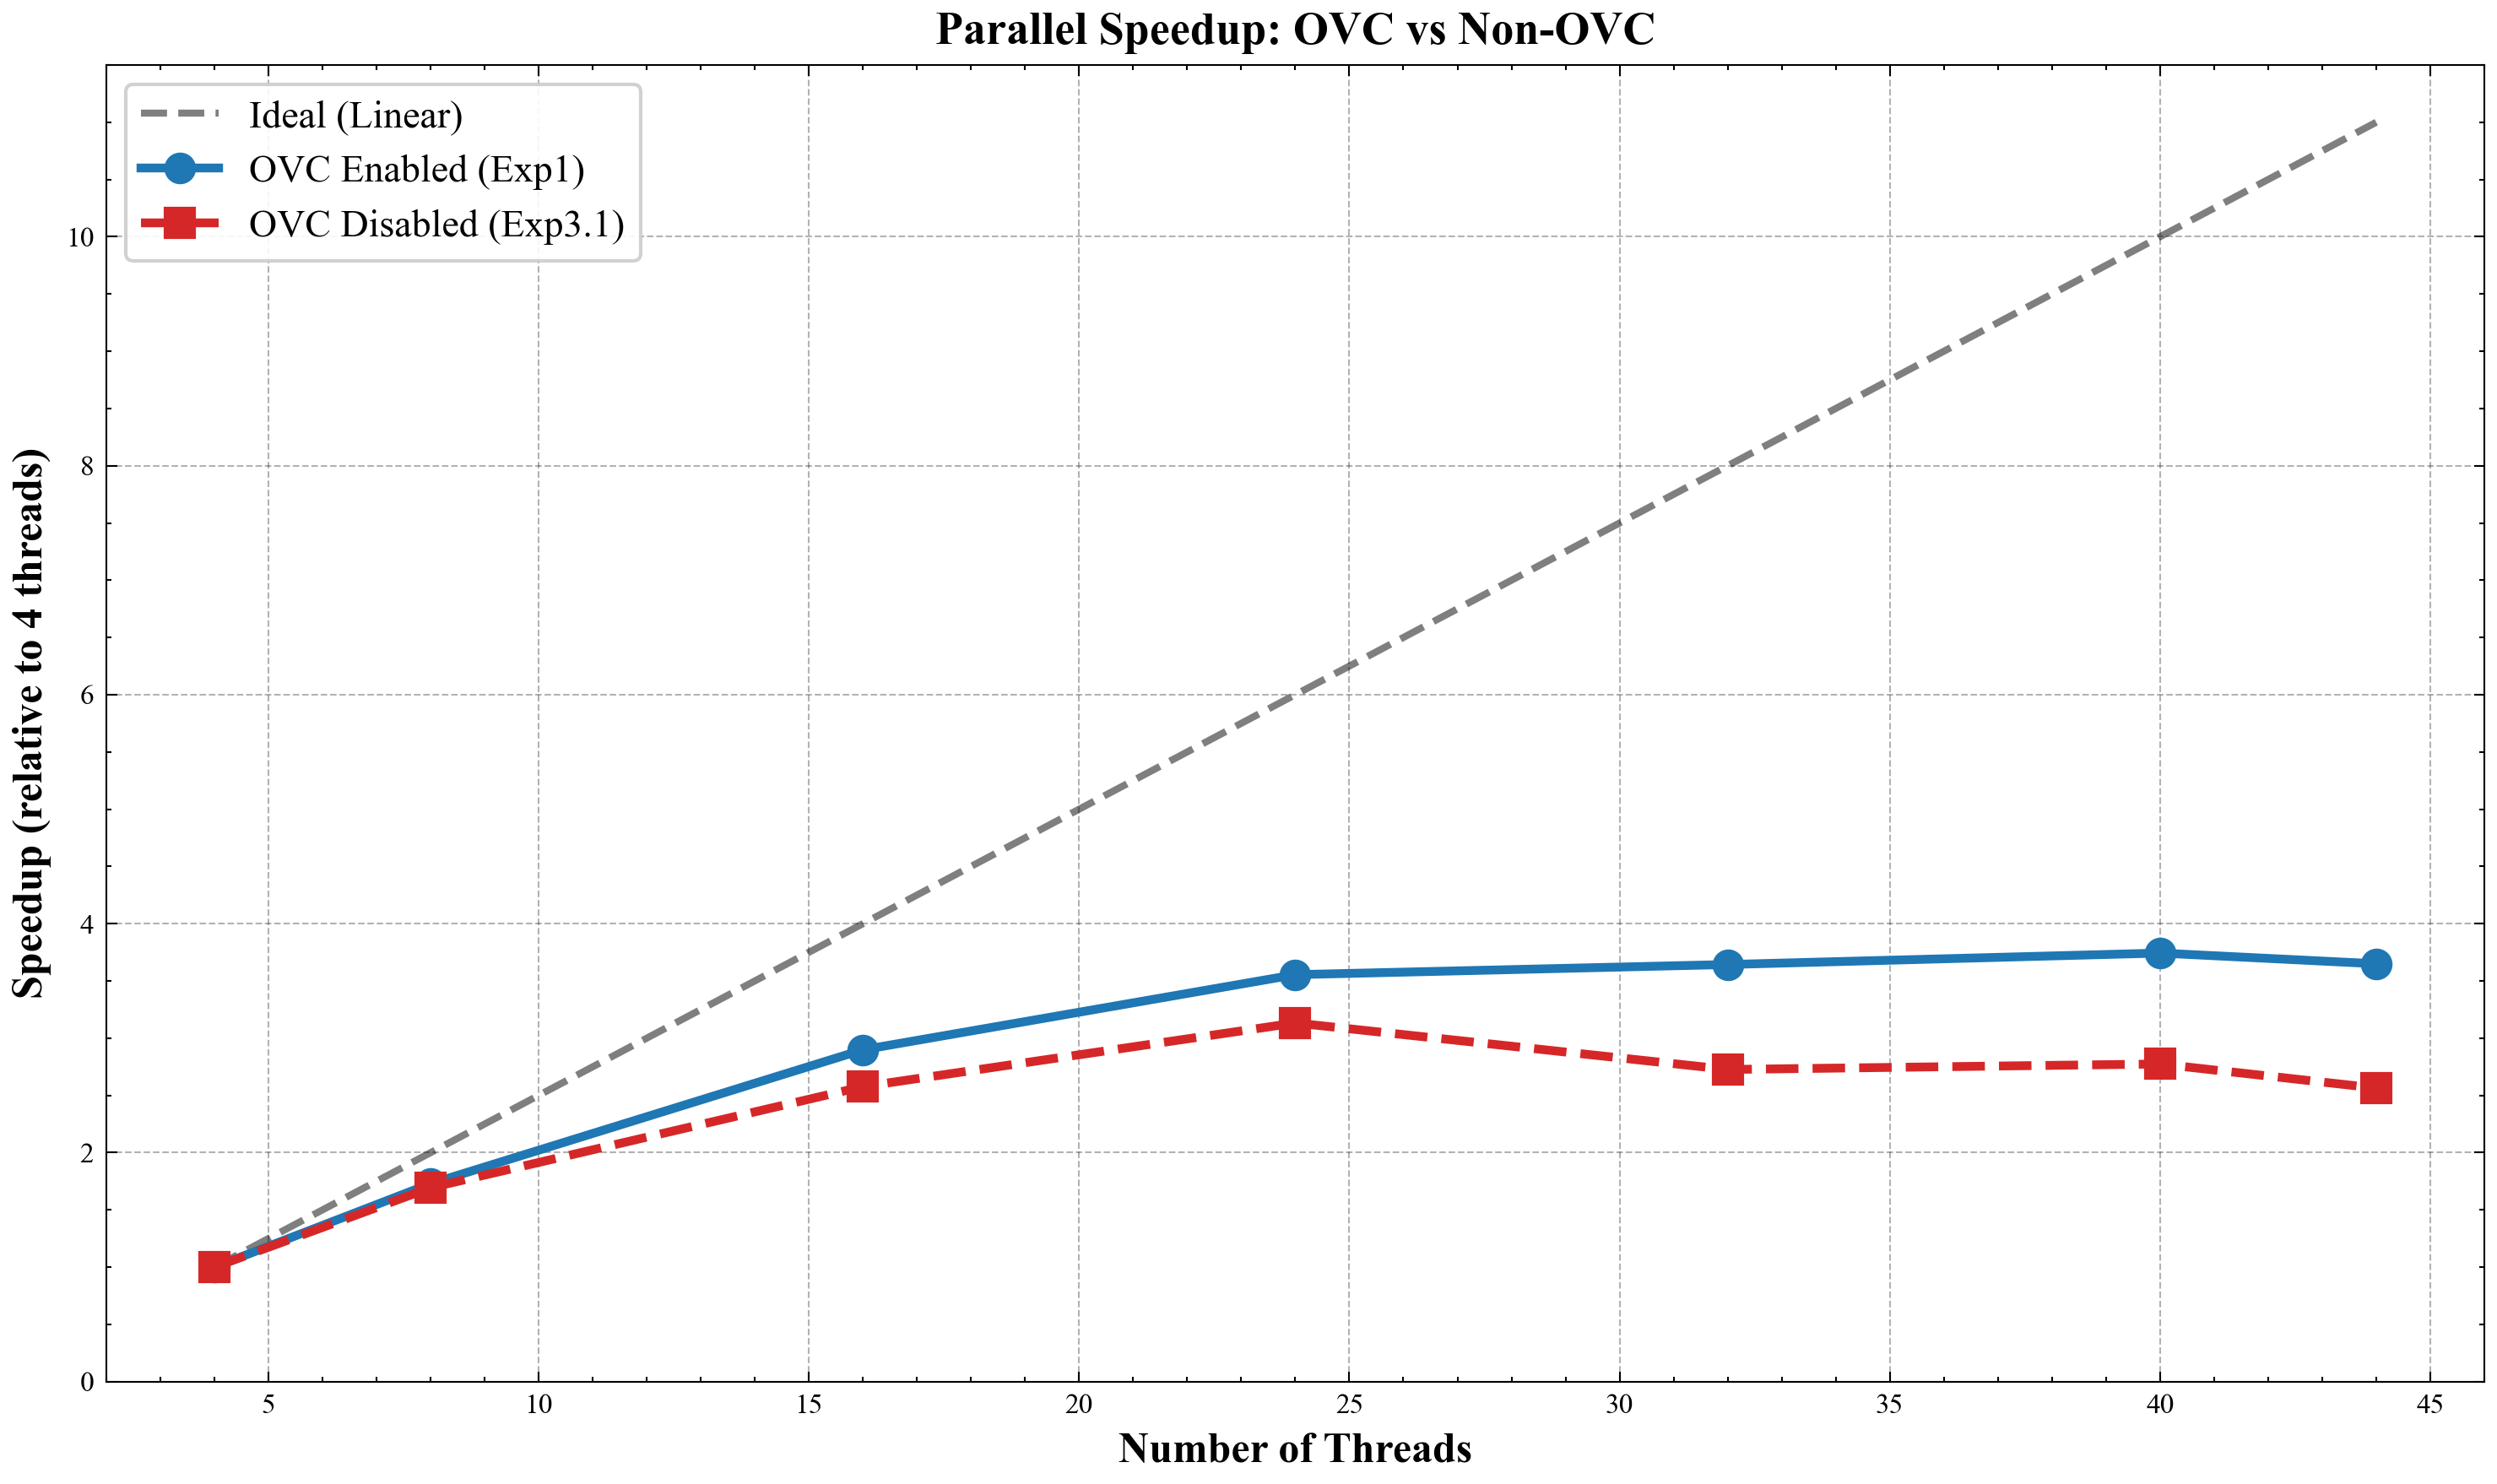

In [13]:
# Exp3.1 Plot 5: Speedup Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    
    baseline_threads = 4
    baseline_time_ovc = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    baseline_time_no_ovc = df_exp3_1_sorted[df_exp3_1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    
    threads = df_exp1_sorted['threads'].values
    ideal_speedup = threads / baseline_threads
    
    speedup_ovc = baseline_time_ovc / df_exp1_sorted['total_time'].values
    speedup_no_ovc = baseline_time_no_ovc / df_exp3_1_sorted['total_time'].values
    
    ax.plot(threads, ideal_speedup, 'k--', lw=2, label='Ideal (Linear)', alpha=0.5)
    ax.plot(threads, speedup_ovc, 'o-', lw=2.5, markersize=8, color='#1f77b4', label='OVC Enabled (Exp1)')
    ax.plot(threads, speedup_no_ovc, 's--', lw=2.5, markersize=8, color='#d62728', label='OVC Disabled (Exp3.1)')
    
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel(f'Speedup (relative to {baseline_threads} threads)', fontweight='bold', fontsize=12)
    ax.set_title('Parallel Speedup: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_speedup_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()


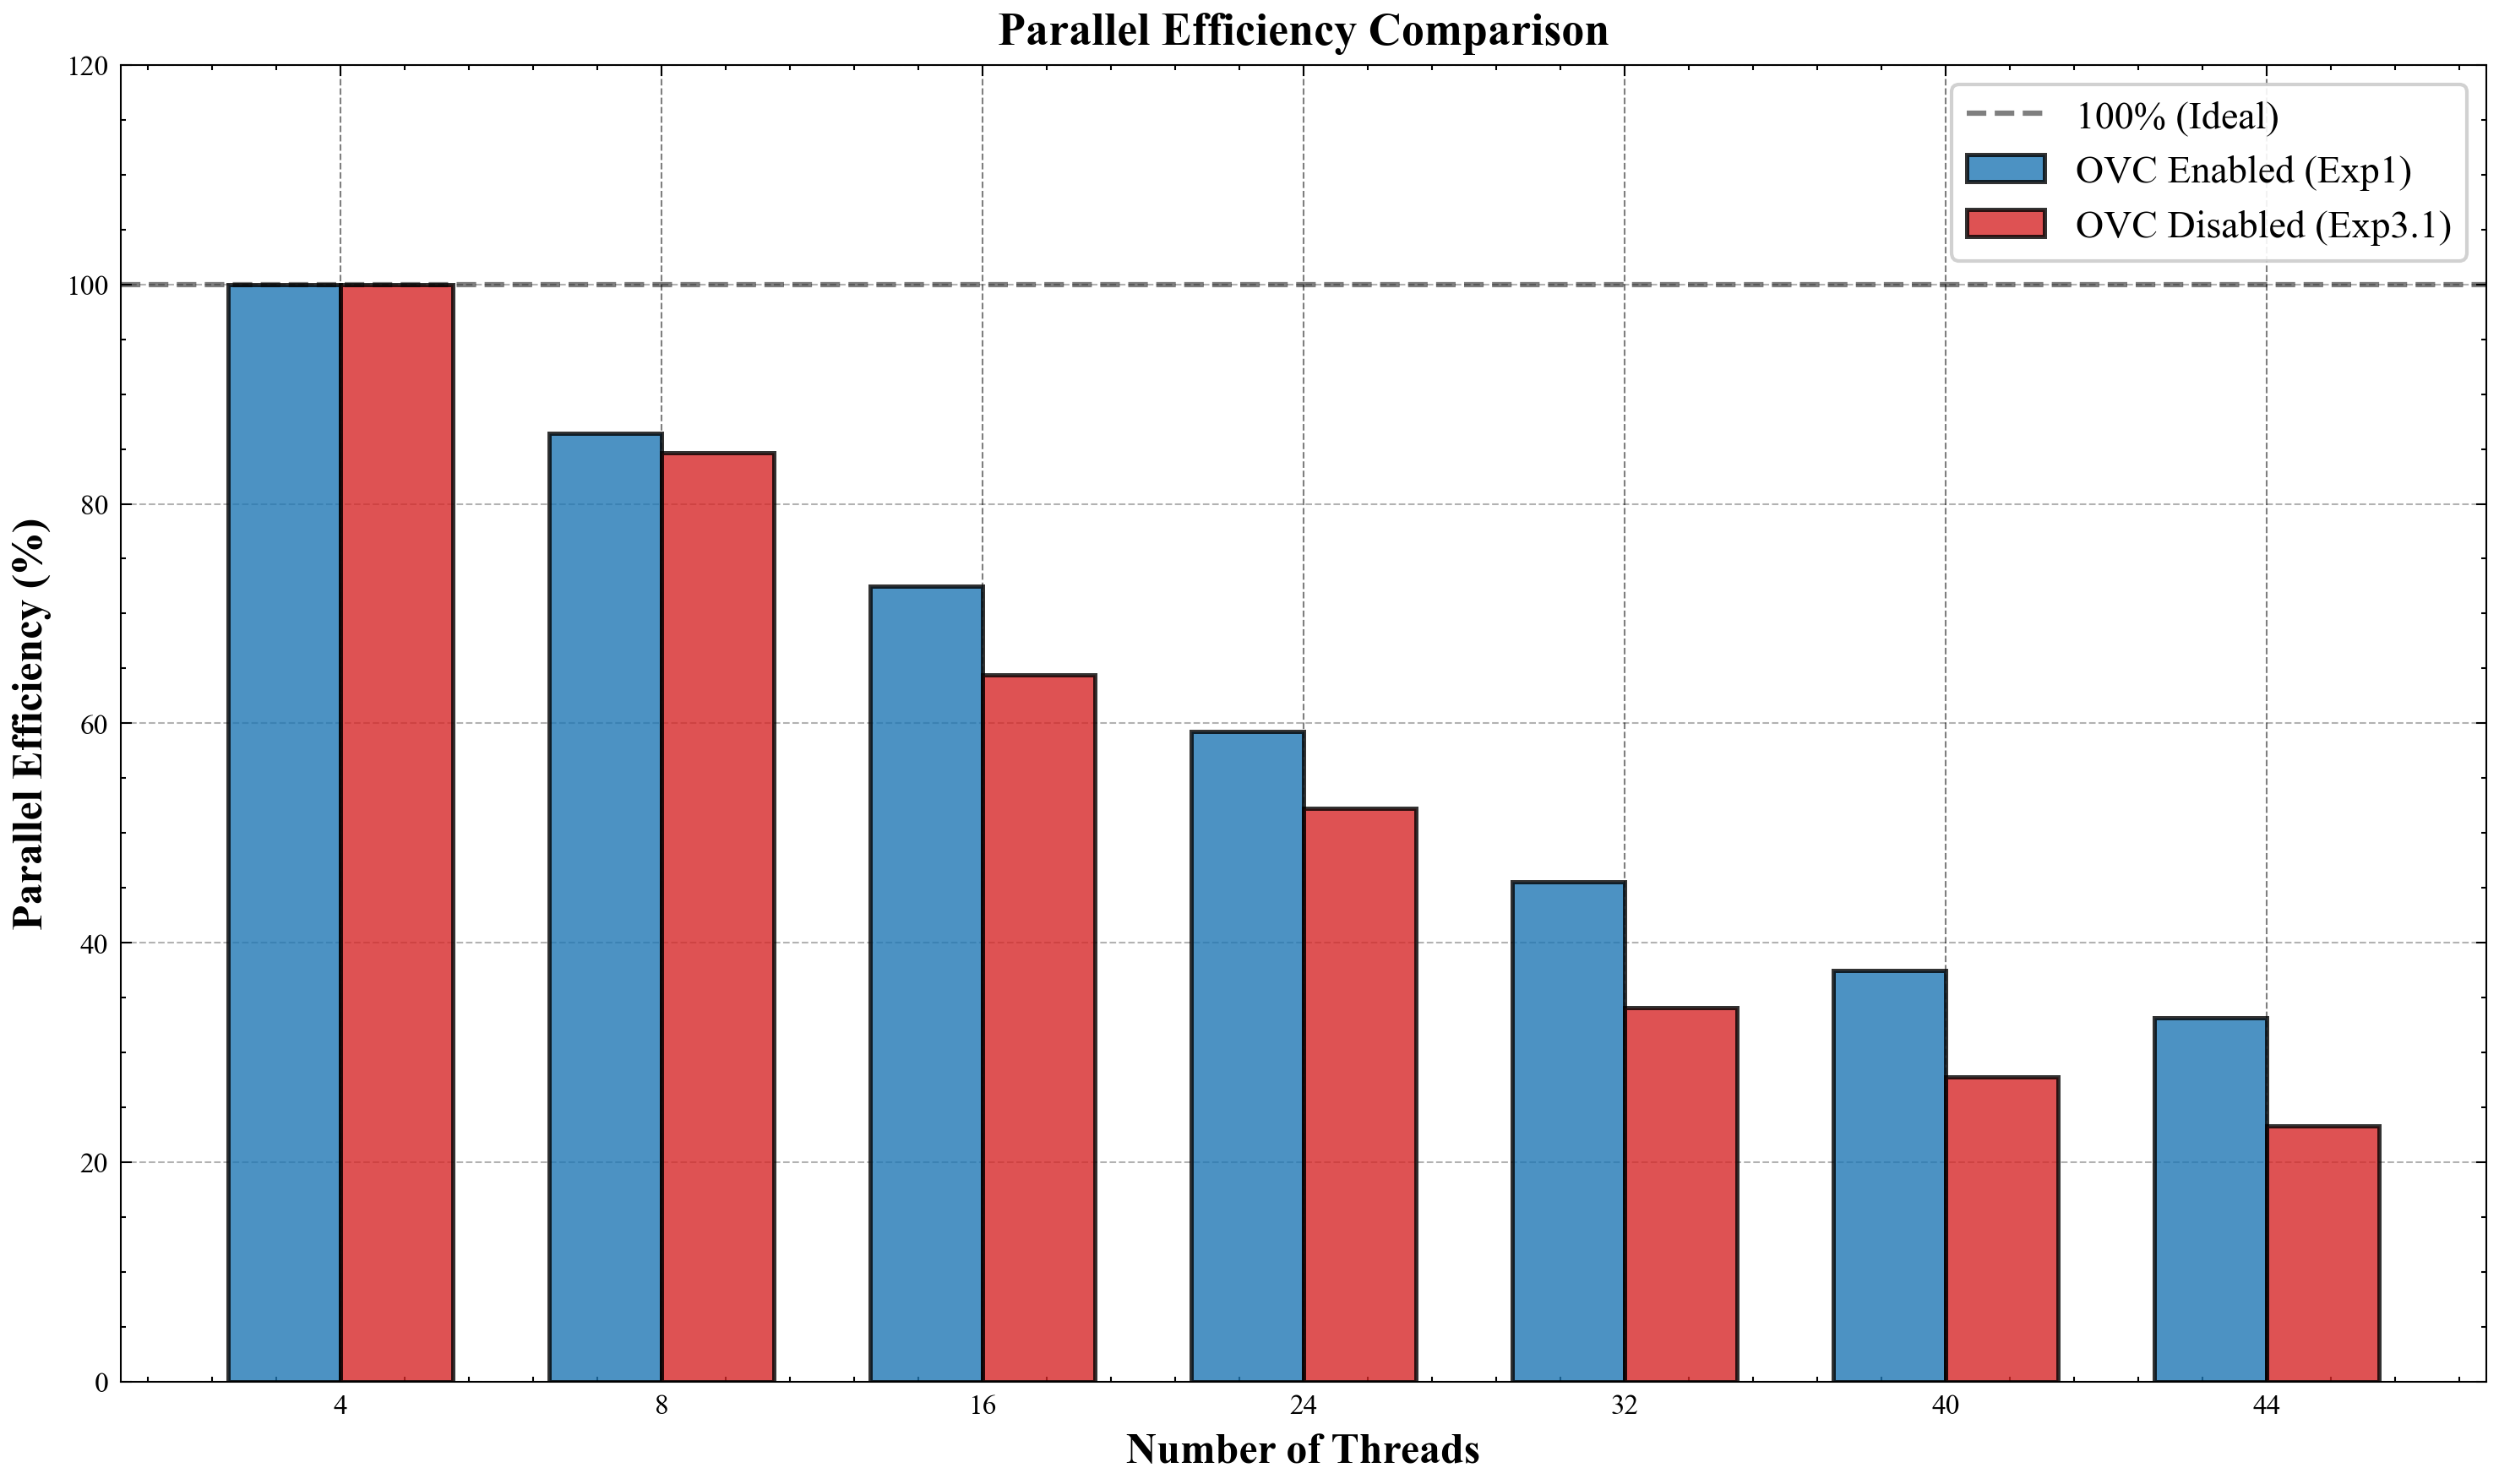


📊 Parallel Efficiency Comparison:
   OVC Enabled - Avg Efficiency: 62.0%
   OVC Disabled - Avg Efficiency: 55.2%


In [14]:
# Exp3.1 Plot 6: Parallel Efficiency
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    
    baseline_threads = 4
    baseline_time_ovc = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    baseline_time_no_ovc = df_exp3_1_sorted[df_exp3_1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    
    threads = df_exp1_sorted['threads'].values
    ideal_speedup = threads / baseline_threads
    
    speedup_ovc = baseline_time_ovc / df_exp1_sorted['total_time'].values
    speedup_no_ovc = baseline_time_no_ovc / df_exp3_1_sorted['total_time'].values
    
    efficiency_ovc = (speedup_ovc / ideal_speedup) * 100
    efficiency_no_ovc = (speedup_no_ovc / ideal_speedup) * 100
    
    width = 0.35
    x_pos = range(len(threads))
    
    ax.bar([x - width/2 for x in x_pos], efficiency_ovc, width, 
           label='OVC Enabled (Exp1)', color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.bar([x + width/2 for x in x_pos], efficiency_no_ovc, width, 
           label='OVC Disabled (Exp3.1)', color='#d62728', alpha=0.8, edgecolor='black', linewidth=1.2)
    
    ax.axhline(y=100, color='black', linestyle='--', lw=1.5, alpha=0.5, label='100% (Ideal)')
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('Parallel Efficiency (%)', fontweight='bold', fontsize=12)
    ax.set_title('Parallel Efficiency Comparison', fontweight='bold', fontsize=13)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(threads)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    ax.set_ylim(0, 120)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_efficiency.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Parallel Efficiency Comparison:")
    print(f"   OVC Enabled - Avg Efficiency: {efficiency_ovc.mean():.1f}%")
    print(f"   OVC Disabled - Avg Efficiency: {efficiency_no_ovc.mean():.1f}%")


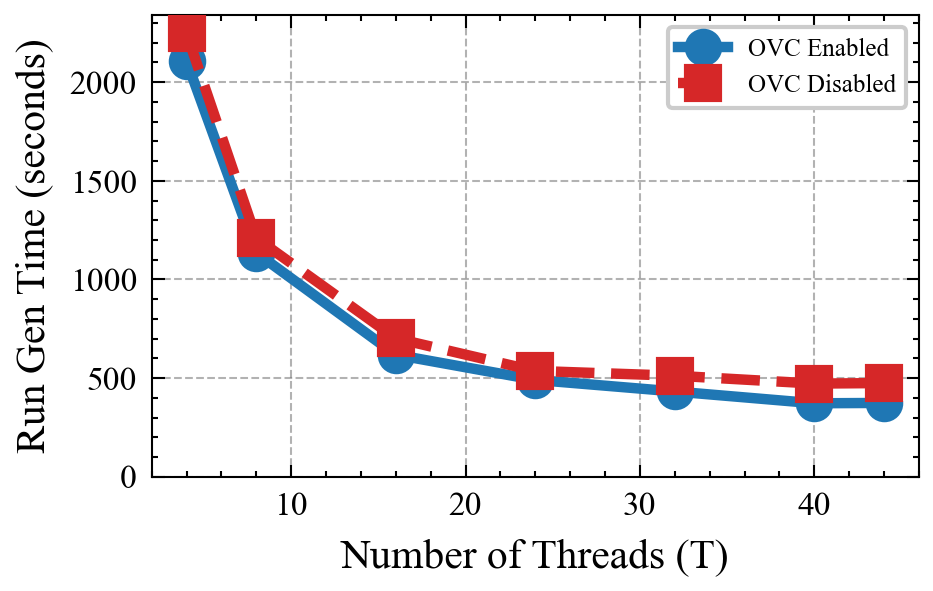

In [15]:
# Exp3.1 Plot 7: Run Generation Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['rungen_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled', zorder=3)
    ax.plot(threads, df_exp3_1_sorted['rungen_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled', zorder=3)
    
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Run Gen Time (seconds)')
    # ax.set_title('Run Generation Phase: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_rungen_time.png'), dpi=300)
    plt.show()


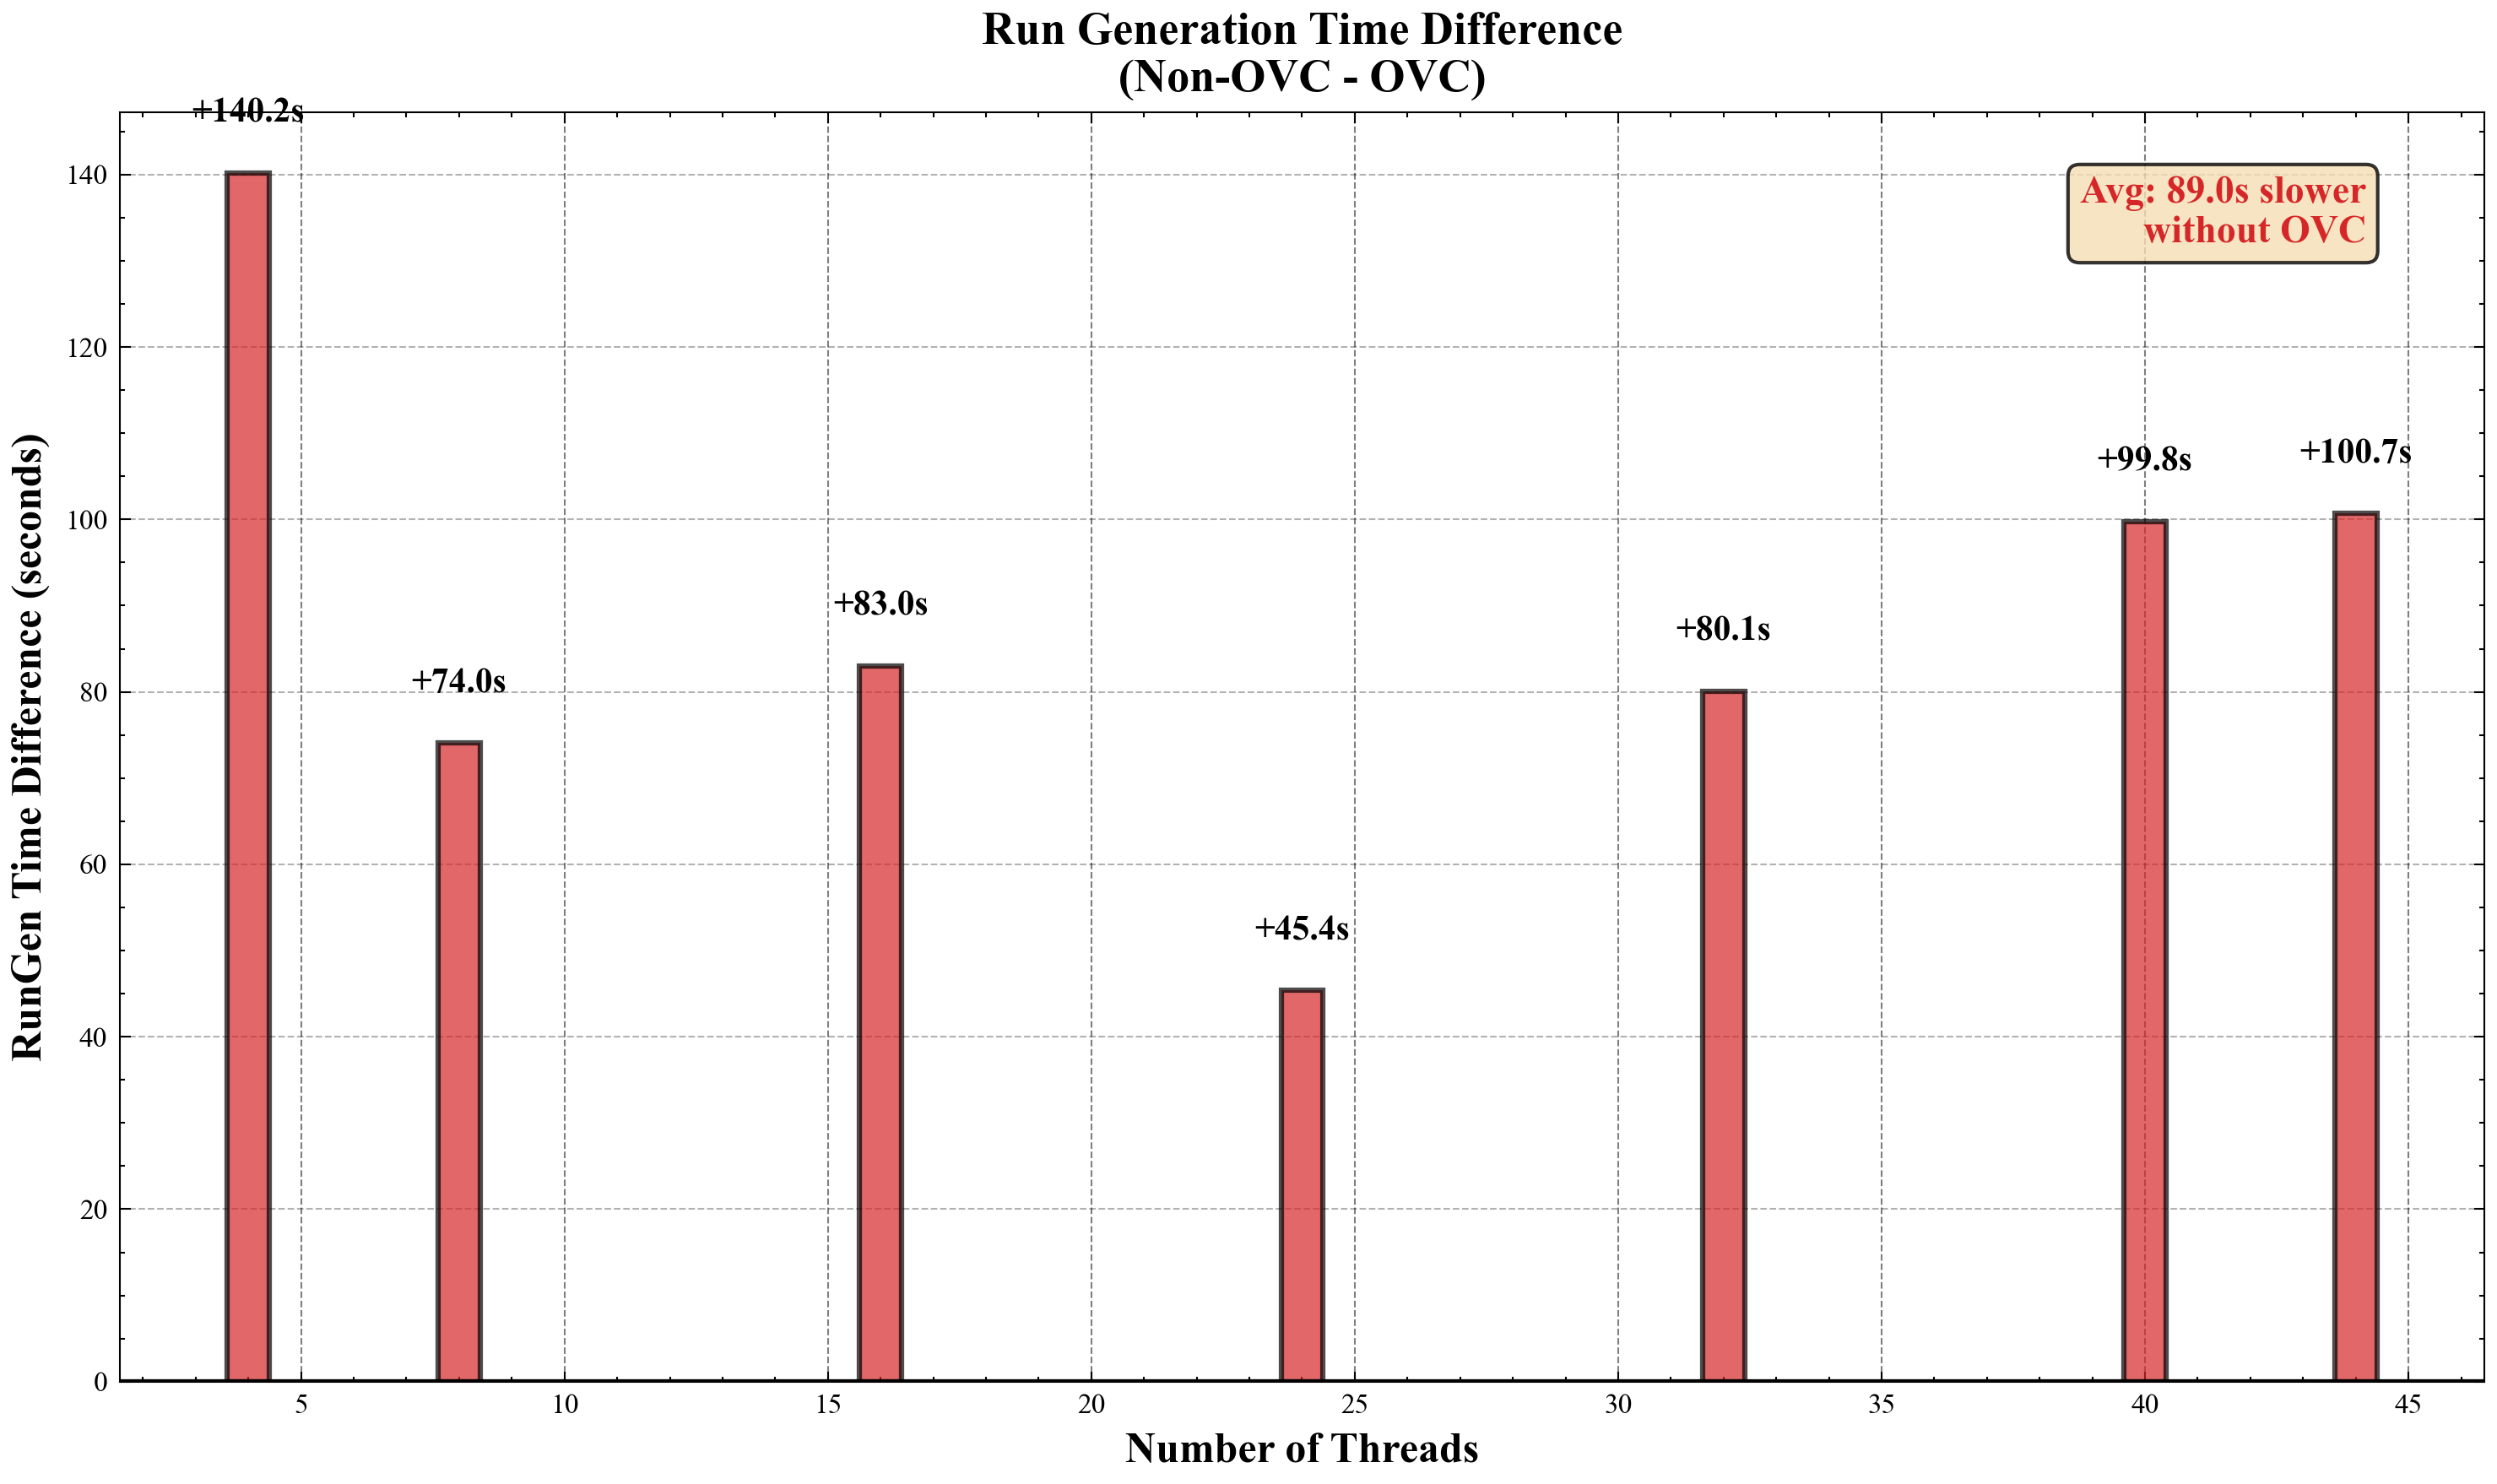


📊 Run Generation Time Analysis:
   Average RunGen diff: +89.0s (slower without OVC)
   Percentage change: +15.4%


In [16]:
# Exp3.1 Plot 8: Run Generation Time Difference
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    rungen_diff = df_exp3_1_sorted['rungen_time'].values - df_exp1_sorted['rungen_time'].values
    bar_colors = ['#2ca02c' if diff < 0 else '#d62728' for diff in rungen_diff]
    
    bars = ax.bar(threads, rungen_diff, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', lw=1.5)
    
    for i, (thread, diff) in enumerate(zip(threads, rungen_diff)):
        label_y = diff + (5 if diff > 0 else -5)
        va = 'bottom' if diff > 0 else 'top'
        ax.text(thread, label_y, f'{diff:+.1f}s', 
                ha='center', va=va, fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('RunGen Time Difference (seconds)', fontweight='bold', fontsize=12)
    ax.set_title('Run Generation Time Difference\n(Non-OVC - OVC)', fontweight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    
    avg_diff = rungen_diff.mean()
    text_color = '#2ca02c' if avg_diff < 0 else '#d62728'
    interpretation = 'faster' if avg_diff < 0 else 'slower'
    ax.text(0.95, 0.95, f'Avg: {abs(avg_diff):.1f}s {interpretation}\nwithout OVC', 
             transform=ax.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11, color=text_color, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_1_rungen_diff.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Run Generation Time Analysis:")
    print(f"   Average RunGen diff: {avg_diff:+.1f}s ({interpretation} without OVC)")
    pct_diff = (rungen_diff / df_exp1_sorted['rungen_time'].values * 100).mean()
    print(f"   Percentage change: {pct_diff:+.1f}%")


#### Exp3.1: Run Generation Time Analysis

### Plot 3: Exp3 - OVC vs NO-OVC Comparison

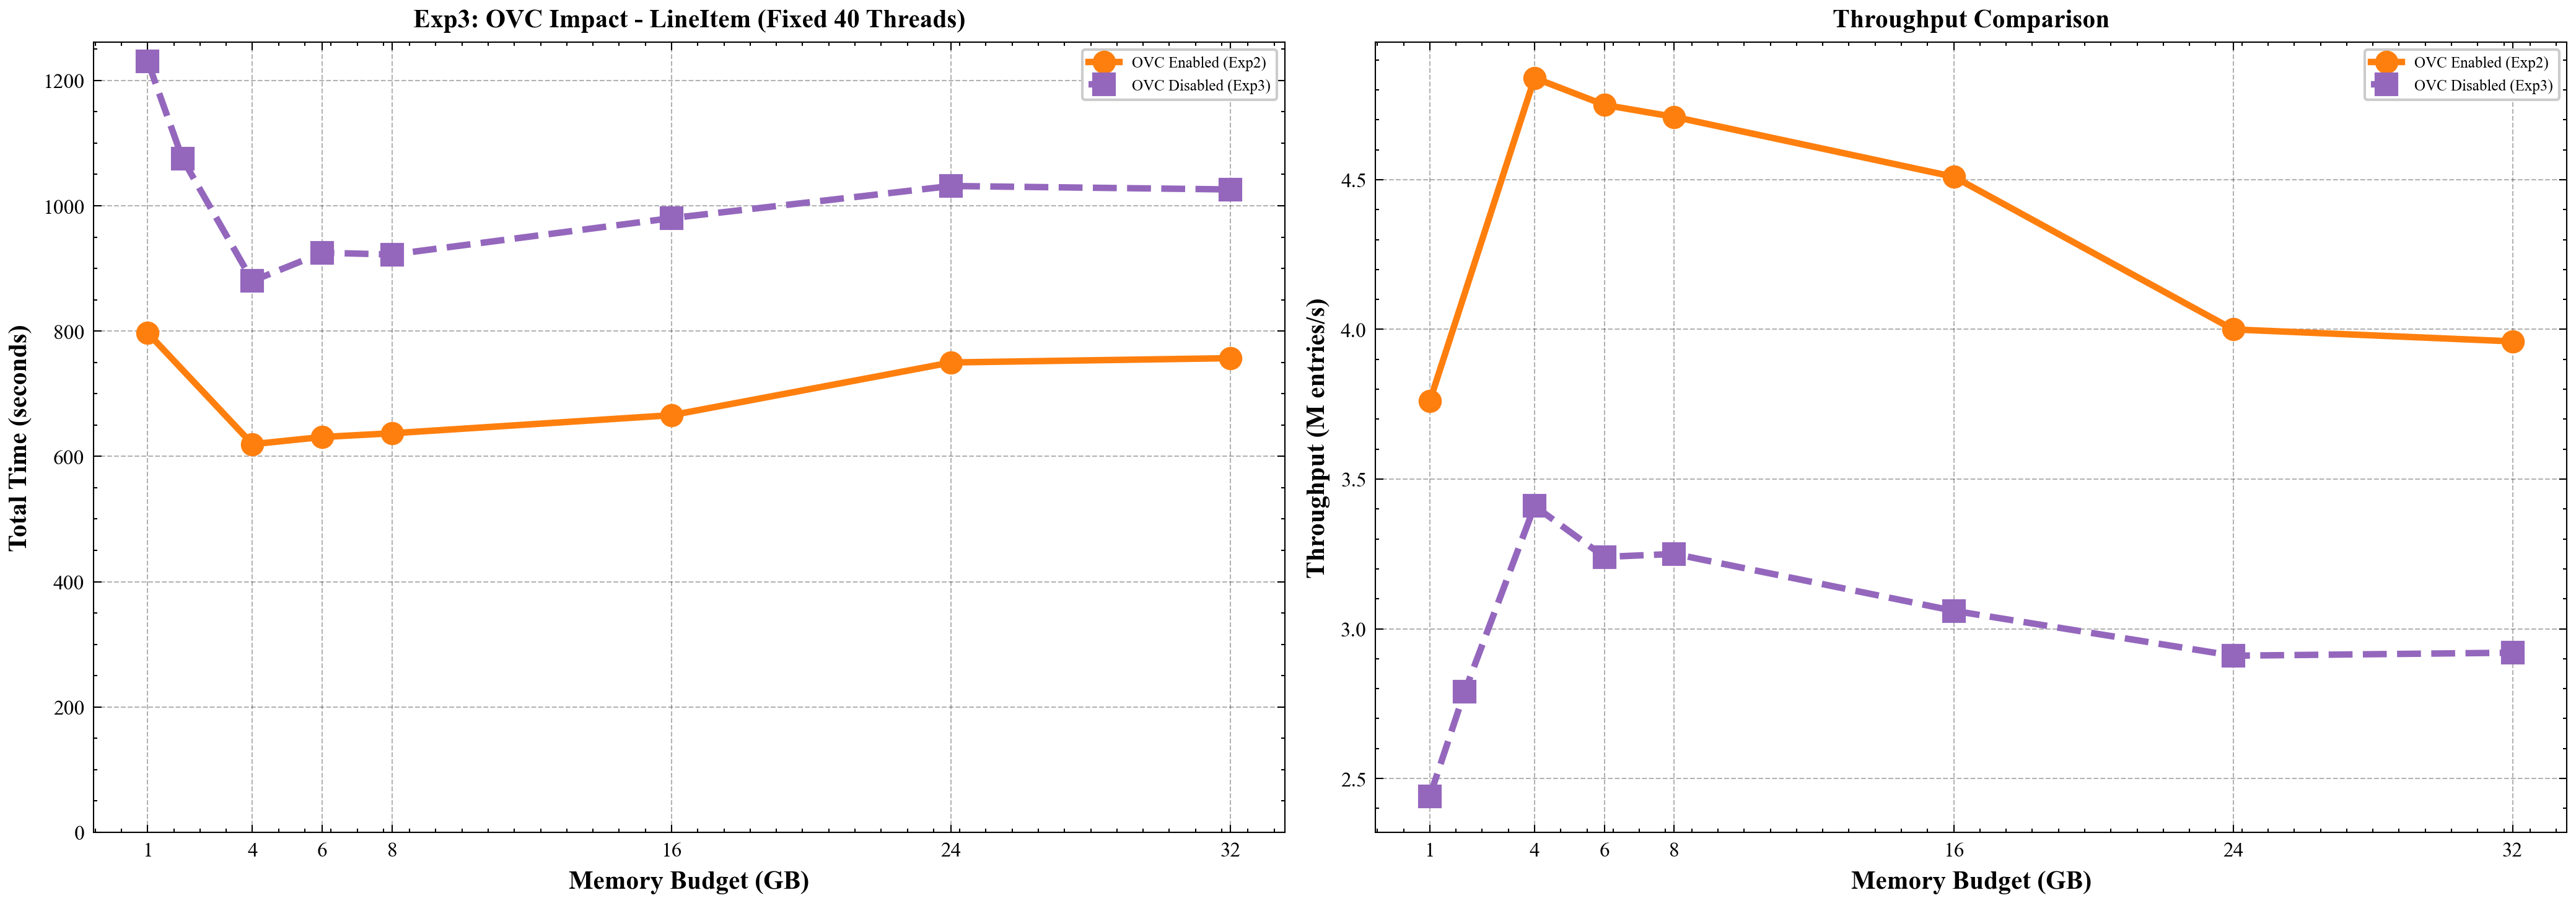


📊 Exp3 Insight: OVC provides 44.0% average speedup across memory configurations.

Per-memory speedup:
 memory_gb  total_time_ovc  total_time_no_ovc   speedup
         1          797.29            1230.80 54.372938
         4          619.49             879.99 42.050719
         6          630.96             925.04 46.608343
         8          636.89             922.23 44.802085
        16          665.78             980.30 47.240830
        24          749.92            1031.58 37.558673
        32          756.77            1026.06 35.584127


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 2a: Total time comparison
df_exp2_sorted = df_exp2.sort_values('memory_gb')
df_exp3_sorted = df_exp3.sort_values('memory_gb')

ax1.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['total_time'], 
         'o-', lw=2.5, markersize=8, color=colors['exp2'], label='OVC Enabled (Exp2)')
ax1.plot(df_exp3_sorted['memory_gb'], df_exp3_sorted['total_time'], 
         's--', lw=2.5, markersize=8, color=colors['exp3'], label='OVC Disabled (Exp3)')

ax1.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax1.set_ylabel('Total Time (seconds)', fontweight='bold')
ax1.set_title('Exp3: OVC Impact - LineItem (Fixed 40 Threads)', fontweight='bold')
ax1.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)

# Plot 2b: Throughput comparison
ax2.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['throughput'], 
         'o-', lw=2.5, markersize=8, color=colors['exp2'], label='OVC Enabled (Exp2)')
ax2.plot(df_exp3_sorted['memory_gb'], df_exp3_sorted['throughput'], 
         's--', lw=2.5, markersize=8, color=colors['exp3'], label='OVC Disabled (Exp3)')

ax2.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax2.set_ylabel('Throughput (M entries/s)', fontweight='bold')
ax2.set_title('Throughput Comparison', fontweight='bold')
ax2.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lineitem_exp3_ovc_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate OVC benefit
merged = pd.merge(df_exp2_sorted[['memory_gb', 'total_time']], 
                  df_exp3_sorted[['memory_gb', 'total_time']], 
                  on='memory_gb', suffixes=('_ovc', '_no_ovc'))
merged['speedup'] = (merged['total_time_no_ovc'] / merged['total_time_ovc'] - 1) * 100
avg_speedup = merged['speedup'].mean()
print(f"\n📊 Exp3 Insight: OVC provides {avg_speedup:.1f}% average speedup across memory configurations.")
print("\nPer-memory speedup:")
print(merged[['memory_gb', 'total_time_ovc', 'total_time_no_ovc', 'speedup']].to_string(index=False))

### OVC vs NO-OVC: Phase Breakdown Analysis


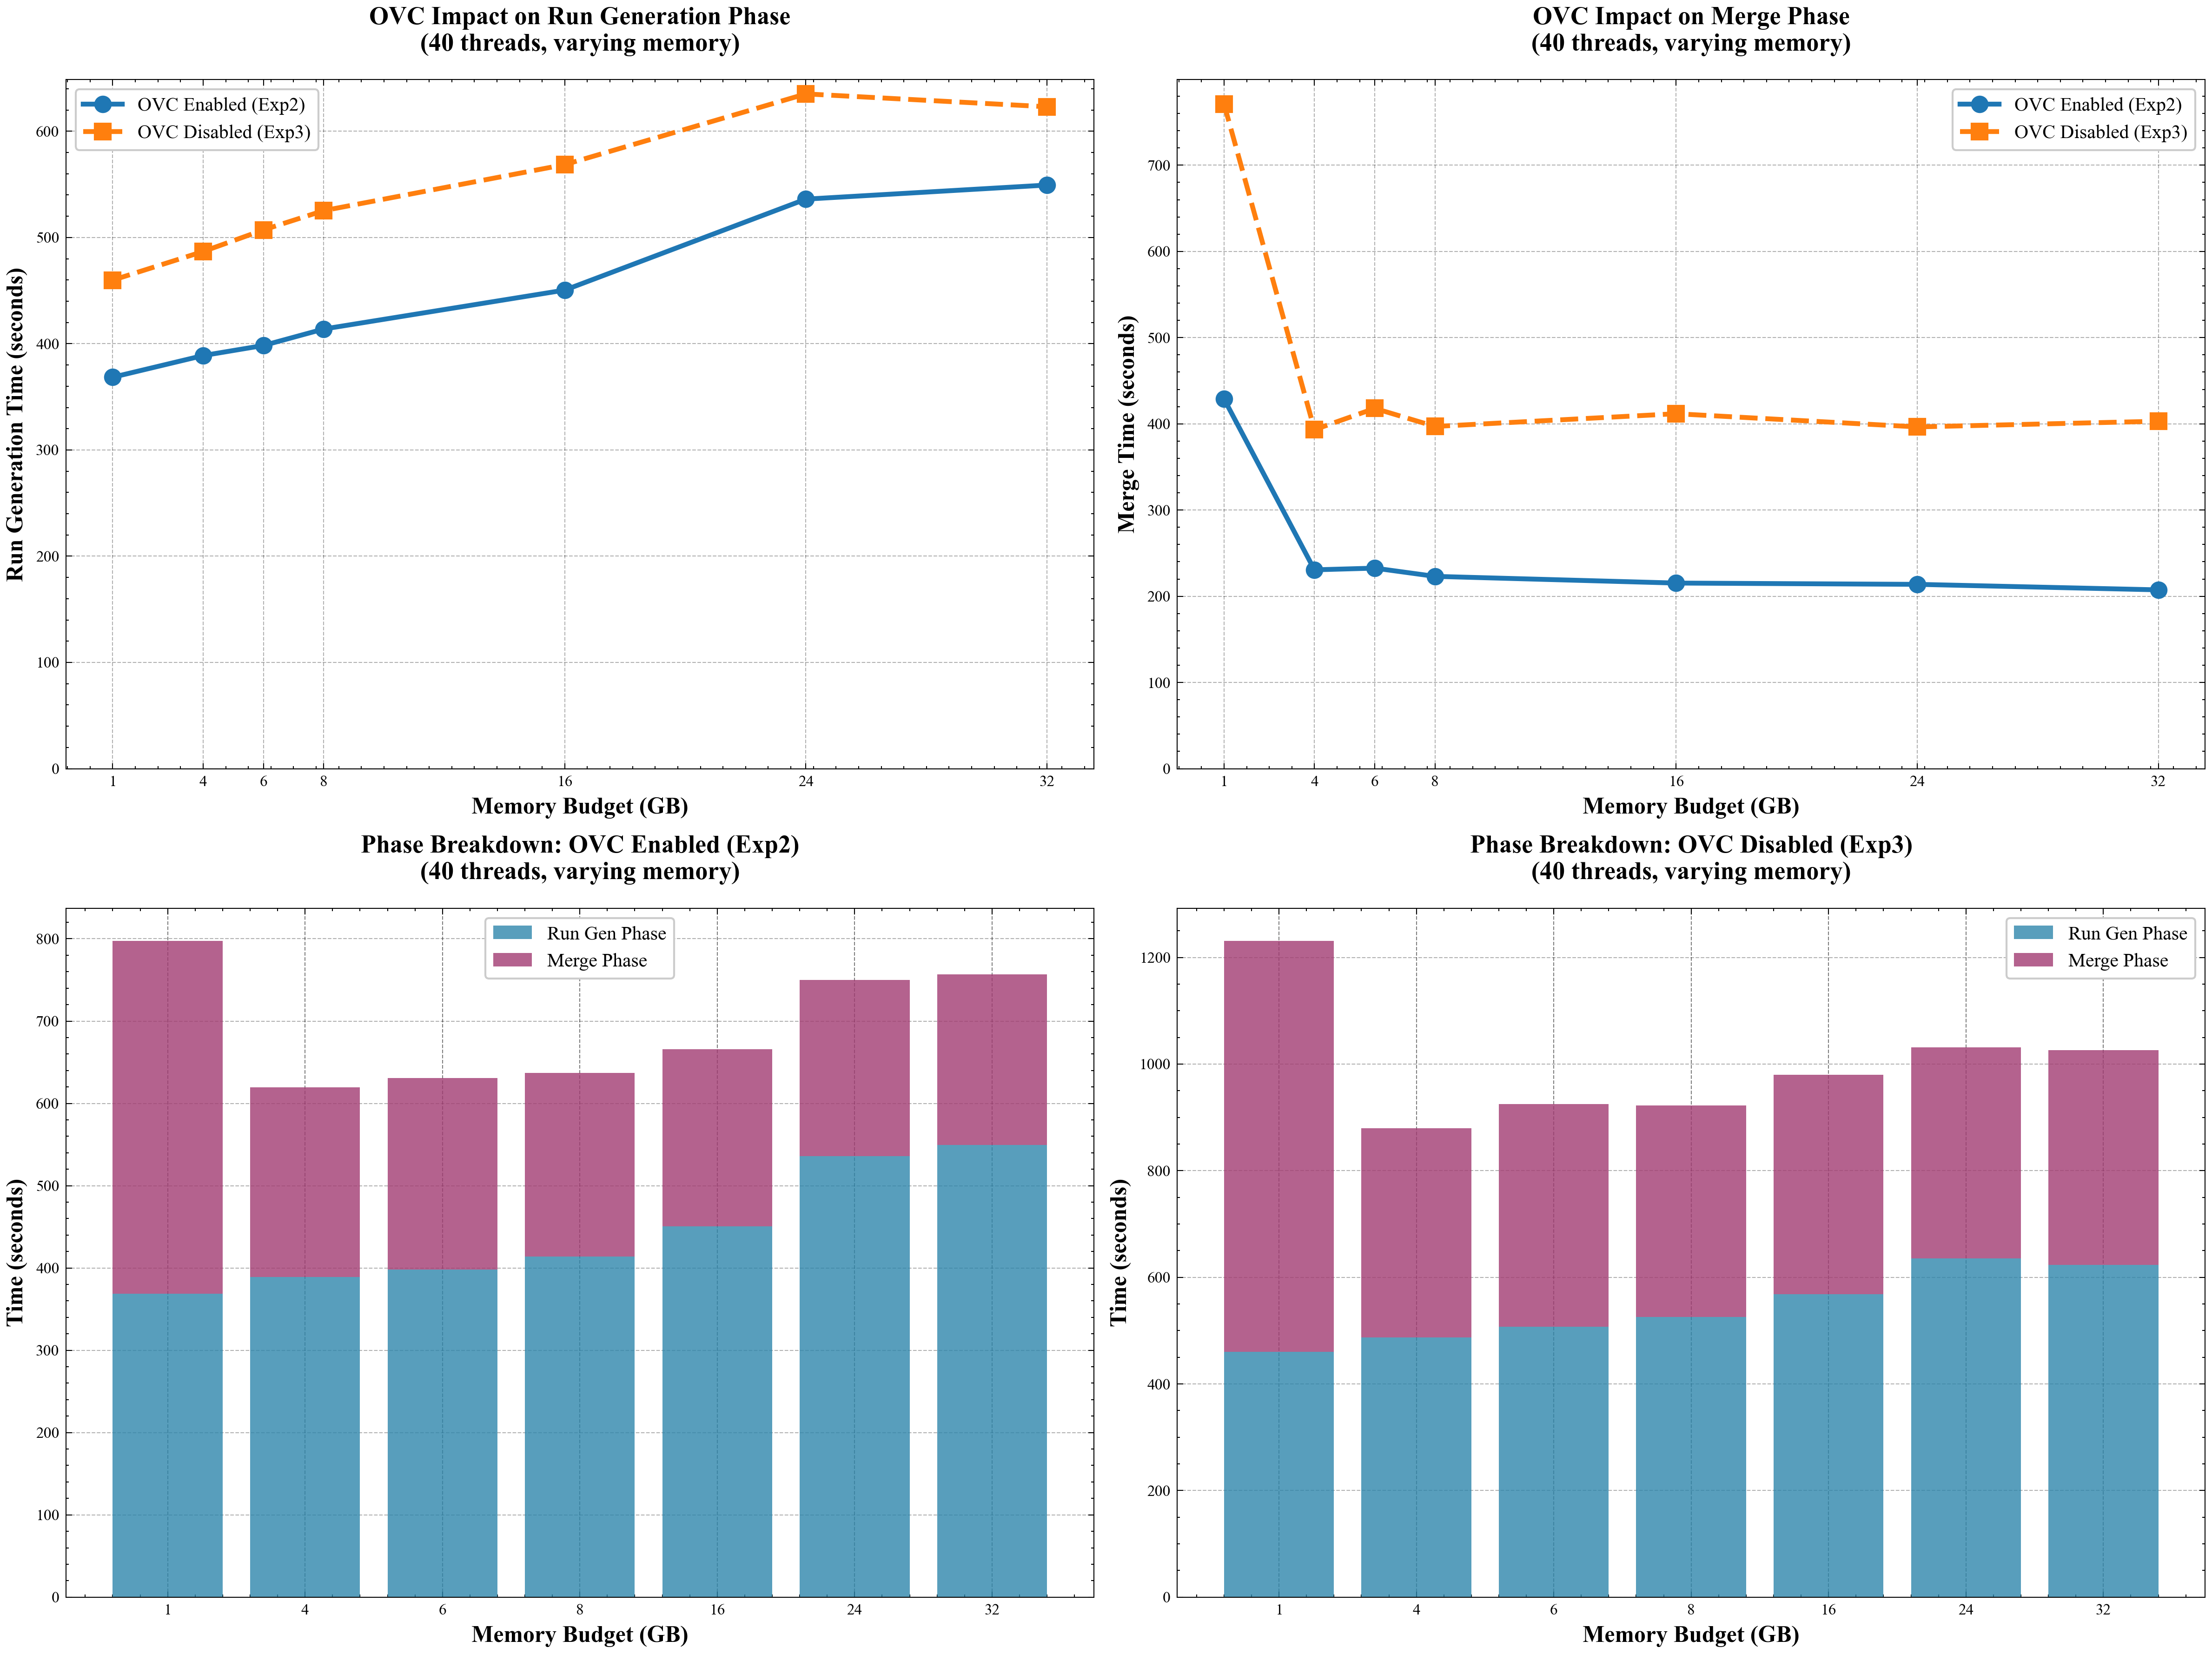


OVC vs NO-OVC: PHASE BREAKDOWN COMPARISON

OVC ENABLED (Exp2):
Memory (GB)  RunGen (s)   Merge (s)    Total (s)   
------------------------------------------------------------
1            368.47       428.81       797.29      
4            388.85       230.64       619.49      
6            398.34       232.61       630.96      
8            413.83       223.06       636.89      
16           450.49       215.29       665.78      
24           536.12       213.80       749.92      
32           549.36       207.41       756.77      

OVC DISABLED (Exp3):
Memory (GB)  RunGen (s)   Merge (s)    Total (s)   
------------------------------------------------------------
1            459.86       770.94       1230.80     
4            486.80       393.19       879.99      
6            507.14       417.90       925.04      
8            525.28       396.95       922.23      
16           568.60       411.70       980.30      
24           635.17       396.41       1031.58     
32          

In [18]:
# OVC vs NO-OVC: Phase Breakdown Analysis
# First, find common memory values between Exp2 and Exp3
df_exp2_sorted = df_exp2.sort_values('memory_gb')
df_exp3_sorted = df_exp3.sort_values('memory_gb')

common_memory = sorted(set(df_exp2_sorted['memory_gb'].values) & set(df_exp3_sorted['memory_gb'].values))

# Filter to common memory values
df_exp2_common = df_exp2_sorted[df_exp2_sorted['memory_gb'].isin(common_memory)].sort_values('memory_gb')
df_exp3_common = df_exp3_sorted[df_exp3_sorted['memory_gb'].isin(common_memory)].sort_values('memory_gb')

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

colors_ovc = {
    'exp2': '#1f77b4',      # OVC enabled
    'exp3': '#ff7f0e',      # OVC disabled
    'rungen': '#2E86AB',
    'merge': '#A23B72'
}

# ----- Plot 1: RunGen Time Comparison -----
ax1.plot(df_exp2_common['memory_gb'], df_exp2_common['rungen_time'],
         'o-', lw=2.5, markersize=8, color=colors_ovc['exp2'], label='OVC Enabled (Exp2)')
ax1.plot(df_exp3_common['memory_gb'], df_exp3_common['rungen_time'],
         's--', lw=2.5, markersize=8, color=colors_ovc['exp3'], label='OVC Disabled (Exp3)')

ax1.set_xlabel('Memory Budget (GB)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Run Generation Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('OVC Impact on Run Generation Phase\n(40 threads, varying memory)',
              fontsize=13, fontweight='bold', pad=15)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(common_memory)
ax1.set_ylim(bottom=0)

# ----- Plot 2: Merge Time Comparison -----
ax2.plot(df_exp2_common['memory_gb'], df_exp2_common['merge_time'],
         'o-', lw=2.5, markersize=8, color=colors_ovc['exp2'], label='OVC Enabled (Exp2)')
ax2.plot(df_exp3_common['memory_gb'], df_exp3_common['merge_time'],
         's--', lw=2.5, markersize=8, color=colors_ovc['exp3'], label='OVC Disabled (Exp3)')

ax2.set_xlabel('Memory Budget (GB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Merge Time (seconds)', fontsize=12, fontweight='bold')
ax2.set_title('OVC Impact on Merge Phase\n(40 threads, varying memory)',
              fontsize=13, fontweight='bold', pad=15)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(common_memory)
ax2.set_ylim(bottom=0)

# ----- Plot 3: Stacked Breakdown - OVC Enabled -----
x_pos = range(len(common_memory))

ax3.bar(x_pos, df_exp2_common['rungen_time'].values,
        label='Run Gen Phase', color=colors_ovc['rungen'], alpha=0.8)
ax3.bar(x_pos, df_exp2_common['merge_time'].values,
        bottom=df_exp2_common['rungen_time'].values,
        label='Merge Phase', color=colors_ovc['merge'], alpha=0.8)

ax3.set_xlabel('Memory Budget (GB)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax3.set_title('Phase Breakdown: OVC Enabled (Exp2)\n(40 threads, varying memory)',
              fontsize=13, fontweight='bold', pad=15)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(common_memory)
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')

# ----- Plot 4: Stacked Breakdown - OVC Disabled -----
ax4.bar(x_pos, df_exp3_common['rungen_time'].values,
        label='Run Gen Phase', color=colors_ovc['rungen'], alpha=0.8)
ax4.bar(x_pos, df_exp3_common['merge_time'].values,
        bottom=df_exp3_common['rungen_time'].values,
        label='Merge Phase', color=colors_ovc['merge'], alpha=0.8)

ax4.set_xlabel('Memory Budget (GB)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax4.set_title('Phase Breakdown: OVC Disabled (Exp3)\n(40 threads, varying memory)',
              fontsize=13, fontweight='bold', pad=15)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(common_memory)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
dataset_name = LOG_DIR.split('/')[-1].replace('_result', '')
plt.savefig(f'{dataset_name}_ovc_phase_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

# Print phase breakdown comparison
print("\n" + "="*80)
print("OVC vs NO-OVC: PHASE BREAKDOWN COMPARISON")
print("="*80)

print("\nOVC ENABLED (Exp2):")
print(f"{'Memory (GB)':<12} {'RunGen (s)':<12} {'Merge (s)':<12} {'Total (s)':<12}")
print("-" * 60)
for _, row in df_exp2_common.iterrows():
    print(f"{row['memory_gb']:<12} {row['rungen_time']:<12.2f} {row['merge_time']:<12.2f} {row['total_time']:<12.2f}")

print("\nOVC DISABLED (Exp3):")
print(f"{'Memory (GB)':<12} {'RunGen (s)':<12} {'Merge (s)':<12} {'Total (s)':<12}")
print("-" * 60)
for _, row in df_exp3_common.iterrows():
    print(f"{row['memory_gb']:<12} {row['rungen_time']:<12.2f} {row['merge_time']:<12.2f} {row['total_time']:<12.2f}")

# Calculate phase-specific impact
print("\n" + "="*80)
print("OVC IMPACT BY PHASE (Common Memory Configurations):")
print("="*80)
print(f"{'Memory (GB)':<12} {'RunGen Diff':<15} {'Merge Diff':<15} {'Total Diff':<15}")
print("-" * 80)

for mem in common_memory:
    exp2_row = df_exp2_common[df_exp2_common['memory_gb'] == mem].iloc[0]
    exp3_row = df_exp3_common[df_exp3_common['memory_gb'] == mem].iloc[0]

    rungen_diff = exp3_row['rungen_time'] - exp2_row['rungen_time']
    merge_diff = exp3_row['merge_time'] - exp2_row['merge_time']
    total_diff = exp3_row['total_time'] - exp2_row['total_time']

    rungen_pct = (rungen_diff / exp2_row['rungen_time']) * 100
    merge_pct = (merge_diff / exp2_row['merge_time']) * 100
    total_pct = (total_diff / exp2_row['total_time']) * 100

    print(f"{mem:<12} {rungen_diff:>6.1f}s ({rungen_pct:>5.1f}%)  {merge_diff:>6.1f}s ({merge_pct:>5.1f}%)  {total_diff:>6.1f}s ({total_pct:>5.1f}%)")

print("\nNote: Positive values mean OVC disabled is slower (OVC helps)")
print("      Negative values mean OVC disabled is faster (OVC hurts)")